# 自编码器（Autoencoder）

自编码器是一种神经网络，经过训练可以通过一个压缩的瓶颈（bottleneck）把输入复制到输出。编码器（Encoder）把输入映射到更低维的潜在空间（Latent Space），解码器（Decoder）则从该潜在表示重建原始输入。

在本 notebook 中，我们在 MNIST 上训练一个自编码器，可视化重建结果在整个训练过程中的改进，并绘制编码器与解码器各层的损失景观（Loss Landscape）——沿用与神经网络 notebook 相同的可视化风格。

导入所需的库

In [1]:
import random
import numpy as np
import io

# %matplotlib ipympl
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image as PILImage

from celluloid import Camera
import scienceplots
from IPython.display import Image

random.seed(0)
np.random.seed(0)
plt.style.use(["science", "no-latex"])


我们将使用 [MNIST](http://yann.lecun.com/exdb/mnist/) 数据集。每张图像为 $28 \times 28$ 像素，在输入自编码器之前会被展平成一个 $784$ 维向量。

我们使用全部 60,000 张图像进行训练。另有一个包含 10,000 张图像的留出集，用来提供 8 个重建可视化样例和 16 个损失景观可视化样例。


In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import random_split, DataLoader, ConcatDataset

torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

mnist_dataset = MNIST(
    root="data/", download=True, train=True, transform=transforms.ToTensor()
)

image_tensor, label = mnist_dataset[0]
print(image_tensor.shape, label)
print(torch.max(image_tensor), torch.min(image_tensor))
plt.imshow(image_tensor[0], cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()


torch.Size([1, 28, 28]) 5
tensor(1.) tensor(0.)


In [3]:
split_generator = torch.Generator().manual_seed(0)
train_data, validation_data, _ = random_split(
    mnist_dataset, [50000, 10000, 0], generator=split_generator
)
train_data = ConcatDataset([train_data, validation_data])

batch_size = 256
loader_generator = torch.Generator().manual_seed(0)
train_loader = DataLoader(
    train_data, batch_size, shuffle=True, generator=loader_generator
)

fixed_images = torch.stack([validation_data[i][0] for i in range(8)])

latent_count = 2000
latent_images = torch.stack([validation_data[i][0] for i in range(latent_count)])
latent_labels = torch.tensor([validation_data[i][1] for i in range(latent_count)])


## 自编码器

自编码器包含两个部分：

1. **编码器** —— 把 $x \in \mathbb{R}^{784}$ 压缩为 $z \in \mathbb{R}^{2}$
2. **解码器** —— 从 $z$ 重建 $\hat{x} \in \mathbb{R}^{784}$

网络最小化 $x$ 与 $\hat{x}$ 之间的 MSE。

### 编码器

$
\begin{align*}
h_1 &= \text{ReLU}(W_1 x + b_1) \\
h_2 &= \text{ReLU}(W_2 h_1 + b_2) \\
h_3 &= \text{ReLU}(W_3 h_2 + b_3) \\
z &= W_4 h_3 + b_4
\end{align*}
$

实现 $784 \rightarrow 512 \rightarrow 256 \rightarrow 64 \rightarrow 2$ 的逐层映射。

### 解码器

$
\begin{align*}
h_4 &= \text{ReLU}(W_5 z + b_5) \\
h_5 &= \text{ReLU}(W_6 h_4 + b_6) \\
h_6 &= \text{ReLU}(W_7 h_5 + b_7) \\
\hat{x} &= \sigma(W_8 h_6 + b_8)
\end{align*}
$

实现 $2 \rightarrow 64 \rightarrow 256 \rightarrow 512 \rightarrow 784$ 的逐层映射。解码器的第一层 $\text{Linear}(2, 64)$ 的每个神经元恰好有 2 个输入权重。

## 损失函数

$
\begin{align*}
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{x}_i)^2
\end{align*}
$

目标就是输入本身——而不是数字标签。

## 绘图函数

绘图函数会生成两个动画：

- `create_reconstruction_plots` —— MSE 曲线，以及原始数字与重建数字
- `create_latent_plots` —— 左侧是潜在空间的大尺寸 2D 散点图，右上角是 MSE 曲线，右下角是重建结果
- `plot_latent_frame` —— 把验证图像投影到 2 神经元瓶颈 $z$ 上并绘制散点，按其真实数字着色，使相同数字的簇在训练过程中逐渐显现
- `show_epoch` —— 控制动画帧的捕获频率

In [4]:
# 为每个数字固定颜色，使重复运行时渲染出的 GIF 始终完全一致。
DIGIT_COLORS = plt.get_cmap("tab10").colors


def create_reconstruction_plots(mse_ylim=(0, 0.08)):
    fig = plt.figure(figsize=(16 / 9.0 * 4, 4 * 1.2), layout="constrained")
    fig.suptitle("Autoencoder Reconstructions")

    gs = fig.add_gridspec(2, 2, width_ratios=[1, 1])
    mse_ax = fig.add_subplot(gs[:, 0])
    orig_ax = fig.add_subplot(gs[0, 1])
    recon_ax = fig.add_subplot(gs[1, 1])

    mse_ax.set_xlabel("Epoch", fontweight="normal")
    mse_ax.set_ylabel("Error", fontweight="normal")
    mse_ax.set_title("Mean Squared Error")
    mse_ax.set_ylim(mse_ylim)

    orig_ax.axis("off")
    orig_ax.set_title("Original")
    recon_ax.axis("off")
    recon_ax.set_title("Reconstructed")

    camera = Camera(fig)
    return mse_ax, orig_ax, recon_ax, camera


def create_latent_plots(mse_ylim=(0, 0.08), epochs=None):
    fig = plt.figure(figsize=(16 / 9.0 * 4, 5), layout="constrained")
    fig.suptitle("Autoencoder Latent Space")

    gs = fig.add_gridspec(2, 2)

    latent_ax = fig.add_subplot(gs[:, 0])
    latent_ax.set_title("Latent Space $z$ (colored by digit)")
    latent_ax.set_xlabel("$z_1$", fontweight="normal")
    latent_ax.set_ylabel("$z_2$", fontweight="normal")
    latent_ax.set_xlim(-25, 25)
    latent_ax.set_ylim(-50, 50)

    mse_ax = fig.add_subplot(gs[0, 1])
    mse_ax.set_xlabel("Epoch", fontweight="normal")
    mse_ax.set_ylabel("Error", fontweight="normal")
    mse_ax.set_title("Mean Squared Error")
    mse_ax.set_ylim(mse_ylim)
    if epochs is not None:
        mse_ax.set_xlim(1, epochs)

    recon_ax = fig.add_subplot(gs[1, 1])
    recon_ax.axis("off")
    recon_ax.set_title("Reconstructions")

    return latent_ax, mse_ax, recon_ax, fig


def capture_figure_frame(fig):
    """Save the current figure to a PIL image (works with 3D axes).

    Uses a fixed figure size (no tight bbox) so every frame has identical
    dimensions and the GIF does not jitter.
    """
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120)
    buf.seek(0)
    return PILImage.open(buf).copy()


def save_pil_gif(frames, filename, duration_ms=200):
    frames[0].save(
        filename,
        save_all=True,
        append_images=frames[1:],
        duration=duration_ms,
        loop=0,
    )


def show_epoch(idx, epochs):
    return (
        idx < 5
        or (idx <= 50 and idx % 10 == 0)
        or (idx > 50 and idx % 25 == 0)
        or idx == epochs - 1
    )


def plot_reconstruction_frame(
    mse_ax, orig_ax, recon_ax, idx, visible_mse, mse_idx, errors, orig, recon
):
    mse_ax.plot(
        mse_idx[visible_mse][: idx + 1],
        errors[visible_mse][: idx + 1],
        color="red",
        alpha=0.5,
    )
    orig_ax.imshow(
        torchvision.utils.make_grid(orig, nrow=4, padding=2)[0].numpy(),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    recon_ax.imshow(
        torchvision.utils.make_grid(recon, nrow=4, padding=2)[0].numpy(),
        cmap="gray",
        vmin=0,
        vmax=1,
    )


def plot_latent_frame(
    latent_ax,
    mse_ax,
    recon_ax,
    model,
    idx,
    visible_mse,
    mse_idx,
    errors,
    recon,
    latent_images,
    latent_labels,
    device,
    latent_state,
):
    """Update the MSE curve, reconstructions, and the 2D latent scatter.

    Each point is a validation image projected to the 2-neuron bottleneck z,
    colored by its true digit. Watching the frames shows same-digit clustering.
    """
    mse_ax.plot(
        mse_idx[visible_mse][: idx + 1],
        errors[visible_mse][: idx + 1],
        color="red",
        alpha=0.5,
    )
    mse_ax.plot([1], [0], color="white", alpha=0)

    recon_ax.imshow(
        torchvision.utils.make_grid(recon, nrow=4, padding=2)[0].numpy(),
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    model.eval()
    with torch.no_grad():
        z = model.encode(latent_images.to(device)).cpu().numpy()

    labels = latent_labels.numpy()
    point_colors = [DIGIT_COLORS[int(digit)] for digit in labels]

    previous = latent_state.get("scatter")
    if previous is not None:
        previous.remove()

    scatter = latent_ax.scatter(
        z[:, 0],
        z[:, 1],
        c=point_colors,
        s=6,
        alpha=0.6,
        linewidths=0,
    )
    latent_state["scatter"] = scatter

    if not latent_state.get("legend_done"):
        handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markersize=5,
                markerfacecolor=DIGIT_COLORS[digit],
                markeredgecolor="none",
                label=str(digit),
            )
            for digit in range(10)
        ]
        latent_ax.legend(
            handles=handles,
            title="Digit",
            loc="upper right",
            fontsize=6,
            ncol=2,
            framealpha=0.6,
        )
        latent_state["legend_done"] = True


def create_3d_plots(mse_ylim=(0, 0.08), epochs=None):
    fig = plt.figure(figsize=(16 / 9.0 * 4, 5), layout="constrained")
    fig.suptitle("Autoencoder Loss Landscape")

    gs = fig.add_gridspec(2, 2)
    layer_axes = []
    all_axes = []

    layer_1 = fig.add_subplot(gs[0, 0], projection="3d")
    layer_1.set_title("Layer 1")
    layer_1.view_init(20, -35)
    layer_axes.append(layer_1)
    all_axes.append(layer_1)

    layer_2 = fig.add_subplot(gs[1, 0], projection="3d")
    layer_2.set_title("Layer 2")
    layer_2.view_init(20, -35)
    layer_axes.append(layer_2)
    all_axes.append(layer_2)

    mse_ax = fig.add_subplot(gs[0, 1])
    mse_ax.set_xlabel("Epoch", fontweight="normal")
    mse_ax.set_ylabel("Error", fontweight="normal")
    mse_ax.set_title("Mean Squared Error")
    mse_ax.set_ylim(mse_ylim)
    if epochs is not None:
        mse_ax.set_xlim(1, epochs)
    all_axes.append(mse_ax)

    recon_ax = fig.add_subplot(gs[1, 1])
    recon_ax.axis("off")
    recon_ax.set_title("Reconstructions")
    all_axes.append(recon_ax)

    return layer_axes, all_axes, fig


def get_landscape_centers(model):
    """Capture initial weights so loss surfaces stay fixed during animation."""
    centers = {}
    for layer_idx in range(2):
        for neuron_idx in range(2):
            init = model.get_values(layer_idx, neuron_idx)
            centers[(layer_idx, neuron_idx)] = (
                init[0].item(),
                init[1].item(),
            )
    return centers


def plot_layer_loss_landscape(
    axis,
    model,
    layer_idx,
    neuron_idx,
    images,
    device,
    w1_center,
    w2_center,
    w1_min=-1,
    w1_max=1,
    w2_min=-1,
    w2_max=1,
    loss_dims=7,
    color="blue",
    axis_limits=None,
    draw_surface=True,
    artists=None,
    history=None,
):
    """Plot loss vs. two weights, with the grid centered on the initial weights.

    When ``draw_surface`` is True the loss surface is (re)computed from the
    model's current state; with the live-surface option enabled this happens
    every frame so the bowl deforms as the other weights change. A marker shows
    the current weights and a trail accumulates past positions so the descent is
    visible. The x/y/z limits are locked to the first frame. Returns the axis
    limits, the dynamic artists ([trail, marker]) and the surface artist (or
    None) separately, so the caller controls which get removed next frame.
    """
    loss_fn = nn.MSELoss()
    flat_images = images.flatten(1).to(device)

    init = model.get_values(layer_idx, neuron_idx)
    w1 = init[0].item()
    w2 = init[1].item()

    with torch.no_grad():
        current_loss = loss_fn(model(flat_images), flat_images).item()

    surface = None
    if draw_surface:
        w1_range = torch.linspace(
            w1_min + w1_center, w1_max + w1_center, loss_dims
        ).to(device)
        w2_range = torch.linspace(
            w2_min + w2_center, w2_max + w2_center, loss_dims
        ).to(device)
        w1_mesh, w2_mesh = torch.meshgrid(w1_range, w2_range, indexing="ij")
        w_pairs = torch.stack((w1_mesh.flatten(), w2_mesh.flatten()), dim=1)

        errors = []
        for pair in w_pairs:
            model.override_layer_weight(layer_idx, neuron_idx, pair)
            with torch.no_grad():
                recon = model(flat_images)
                errors.append(loss_fn(recon, flat_images).item())

        z_grid = np.array(errors).reshape(loss_dims, loss_dims)
        surface = axis.plot_surface(
            w1_mesh.detach().cpu().numpy(),
            w2_mesh.detach().cpu().numpy(),
            z_grid,
            color=color,
            alpha=0.1,
        )
        model.override_layer_weight(layer_idx, neuron_idx, init)

        if axis_limits is None:
            axis.set_xlim(w1_min + w1_center, w1_max + w1_center)
            axis.set_ylim(w2_min + w2_center, w2_max + w2_center)
            # 把 z 轴的下限固定为 0，这样下降中的标记就不会被裁掉。
            axis.set_zlim(0, float(z_grid.max()))
            axis_limits = axis.get_xlim(), axis.get_ylim(), axis.get_zlim()
        else:
            axis.set_xlim(axis_limits[0])
            axis.set_ylim(axis_limits[1])
            axis.set_zlim(axis_limits[2])

    history.append((w1, w2, current_loss))
    if artists:
        for artist in artists:
            if artist is not None:
                artist.remove()

    xs = [p[0] for p in history]
    ys = [p[1] for p in history]
    zs = [p[2] for p in history]
    (trail,) = axis.plot(xs, ys, zs, color=color, alpha=0.7, linewidth=1.5)
    marker = axis.scatter(
        [w1],
        [w2],
        [current_loss],
        color=color,
        s=45,
        edgecolors="black",
        linewidths=0.6,
        depthshade=False,
        zorder=10,
    )
    return axis_limits, [trail, marker], surface


def plot_loss_landscape_frame(
    layer_axes,
    all_axes,
    model,
    idx,
    visible_mse,
    mse_idx,
    errors,
    recon,
    landscape_images,
    device,
    landscape_centers,
    layer_axis_limits,
    landscape_state,
    live_surface=False,
):
    mse_ax = all_axes[2]
    recon_ax = all_axes[3]

    # 实时模式下每帧都会重绘曲面；否则只绘制一次。
    if live_surface:
        draw_surfaces = True
    else:
        draw_surfaces = not landscape_state.get("surfaces_done", False)

    mse_ax.plot(
        mse_idx[visible_mse][: idx + 1],
        errors[visible_mse][: idx + 1],
        color="red",
        alpha=0.5,
    )
    mse_ax.plot([1], [0], color="white", alpha=0)

    recon_ax.imshow(
        torchvision.utils.make_grid(recon, nrow=4, padding=2)[0].numpy(),
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    for layer_idx, axis in enumerate(layer_axes):
        limits = layer_axis_limits[layer_idx]
        for neuron_idx, color in enumerate(["blue", "red"]):
            w1_center, w2_center = landscape_centers[(layer_idx, neuron_idx)]
            key = (layer_idx, neuron_idx)
            history = landscape_state.setdefault(("history", key), [])

            # 始终刷新圆点和轨迹；只有当我们
            # 准备绘制替代曲面（实时模式）时才移除旧曲面。
            to_remove = list(landscape_state.get(("dynamic", key), []))
            prev_surface = landscape_state.get(("surface", key))
            if live_surface and prev_surface is not None:
                to_remove.append(prev_surface)

            limits, dynamic, surface = plot_layer_loss_landscape(
                axis,
                model,
                layer_idx,
                neuron_idx,
                landscape_images,
                device,
                w1_center,
                w2_center,
                color=color,
                axis_limits=limits,
                draw_surface=draw_surfaces,
                artists=to_remove,
                history=history,
            )
            landscape_state[("dynamic", key)] = dynamic
            if surface is not None:
                landscape_state[("surface", key)] = surface
            if layer_axis_limits[layer_idx] is None:
                layer_axis_limits[layer_idx] = limits

    landscape_state["surfaces_done"] = True


## PyTorch 实现

`layers` 列表存储了我们在损失景观中可视化的两层：

1. `enc_fc4` —— 编码器 $\text{Linear}(64, 2)$
2. `dec_fc1` —— 解码器 $\text{Linear}(2, 64)$

In [5]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=64, hidden=256, extra_layer=True):
        super().__init__()
        self.extra_layer = extra_layer
        if extra_layer:
            self.enc_fc1 = nn.Linear(28 * 28, 512)
            self.enc_fc2 = nn.Linear(512, hidden)
            self.enc_fc3 = nn.Linear(hidden, latent_dim)
            self.enc_fc4 = nn.Linear(latent_dim, 2)
            self.dec_fc1 = nn.Linear(2, latent_dim)
            self.dec_fc2 = nn.Linear(latent_dim, hidden)
            self.dec_fc3 = nn.Linear(hidden, 512)
            self.dec_fc4 = nn.Linear(512, 28 * 28)
            self.layers = nn.ModuleList([self.enc_fc4, self.dec_fc1])
        else:
            self.enc_fc1 = nn.Linear(28 * 28, hidden)
            self.enc_fc2 = nn.Linear(hidden, latent_dim)
            self.enc_fc3 = nn.Linear(latent_dim, 2)
            self.dec_fc1 = nn.Linear(2, latent_dim)
            self.dec_fc2 = nn.Linear(latent_dim, hidden)
            self.dec_fc3 = nn.Linear(hidden, 28 * 28)
            self.layers = nn.ModuleList([self.enc_fc3, self.dec_fc1])

    def forward(self, x):
        if x.dim() > 2:
            x = x.flatten(1)
        if self.extra_layer:
            h = torch.relu(self.enc_fc1(x))
            h = torch.relu(self.enc_fc2(h))
            h = torch.relu(self.enc_fc3(h))
            z = self.enc_fc4(h)
            h = torch.relu(self.dec_fc1(z))
            h = torch.relu(self.dec_fc2(h))
            h = torch.relu(self.dec_fc3(h))
            return torch.sigmoid(self.dec_fc4(h))
        h = torch.relu(self.enc_fc1(x))
        h = torch.relu(self.enc_fc2(h))
        z = self.enc_fc3(h)
        h = torch.relu(self.dec_fc1(z))
        h = torch.relu(self.dec_fc2(h))
        return torch.sigmoid(self.dec_fc3(h))

    def encode(self, x):
        if x.dim() > 2:
            x = x.flatten(1)
        if self.extra_layer:
            h = torch.relu(self.enc_fc1(x))
            h = torch.relu(self.enc_fc2(h))
            h = torch.relu(self.enc_fc3(h))
            return self.enc_fc4(h)
        h = torch.relu(self.enc_fc1(x))
        h = torch.relu(self.enc_fc2(h))
        return self.enc_fc3(h)

    def get_values(self, layer_idx, neuron_idx=0):
        with torch.no_grad():
            return self.layers[layer_idx].weight.detach().clone()[neuron_idx, :2]

    def override_layer_weight(self, layer_idx, neuron_idx, new_weights):
        with torch.no_grad():
            self.layers[layer_idx].weight[neuron_idx, :2] = new_weights

## 训练模型

`fit` 函数会生成三个动画：

1. `autoencoder.gif` —— 重建损失与数字重建
2. `autoencoder_latent_space.gif` —— 按数字着色的 2D 潜在空间，以及 MSE 曲线和重建结果
3. `autoencoder_loss_landscape.gif` —— 逐层的 3D 损失曲面（两个神经元分别为蓝色和红色）、MSE 曲线与重建结果

设置 `recon_only = True` 可以跳过潜在空间与损失景观 GIF，只生成 `autoencoder.gif`（更快）。

In [6]:
def fit(
    model,
    train_loader,
    fixed_images,
    latent_images,
    latent_labels,
    epochs,
    learning_rate,
    recon_filename,
    latent_filename,
    landscape_filename,
    recon_only=False,
    live_surface=False,
):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    fixed = fixed_images.to(device)

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    mse_idx = np.arange(1, epochs + 1)
    errors = np.full(epochs, -1.0)

    mse_ax, orig_ax, recon_ax, recon_camera = create_reconstruction_plots()

    if recon_only:
        latent_ax = latent_mse_ax = latent_recon_ax = latent_fig = None
        latent_state = None
        latent_frames = []
        layer_axes = all_axes = landscape_fig = None
        landscape_images = landscape_centers = None
        layer_axis_limits = landscape_state = None
        landscape_frames = []
    else:
        latent_ax, latent_mse_ax, latent_recon_ax, latent_fig = create_latent_plots(
            epochs=epochs
        )
        latent_state = {}
        latent_frames = []

        landscape_images = latent_images[:16]
        landscape_centers = get_landscape_centers(model)
        layer_axis_limits = [None, None]
        landscape_state = {}
        layer_axes, all_axes, landscape_fig = create_3d_plots(epochs=epochs)
        landscape_frames = []

    for idx in range(epochs):
        model.train()
        epoch_loss = 0.0
        batches = 0

        for images, _ in train_loader:
            images = images.to(device).flatten(1)
            reconstructions = model(images)
            loss = loss_fn(reconstructions, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            batches += 1

        errors[idx] = epoch_loss / batches
        scheduler.step()

        if show_epoch(idx, epochs):
            print(f"epoch: {idx}, MSE: {errors[idx]:.4f}")

            model.eval()
            with torch.no_grad():
                recon = model(fixed.flatten(1)).view(-1, 1, 28, 28).cpu()
            orig = fixed.view(-1, 1, 28, 28).cpu()
            visible = errors != -1

            plot_reconstruction_frame(
                mse_ax, orig_ax, recon_ax, idx, visible, mse_idx, errors, orig, recon
            )
            recon_camera.snap()

            if not recon_only:
                plot_latent_frame(
                    latent_ax,
                    latent_mse_ax,
                    latent_recon_ax,
                    model,
                    idx,
                    visible,
                    mse_idx,
                    errors,
                    recon,
                    latent_images,
                    latent_labels,
                    device,
                    latent_state,
                )
                latent_fig.canvas.draw()
                latent_frames.append(capture_figure_frame(latent_fig))

                plot_loss_landscape_frame(
                    layer_axes,
                    all_axes,
                    model,
                    idx,
                    visible,
                    mse_idx,
                    errors,
                    recon,
                    landscape_images,
                    device,
                    landscape_centers,
                    layer_axis_limits,
                    landscape_state,
                    live_surface=live_surface,
                )
                landscape_fig.canvas.draw()
                landscape_frames.append(capture_figure_frame(landscape_fig))

    if not recon_only:
        save_pil_gif(latent_frames, latent_filename)
        save_pil_gif(landscape_frames, landscape_filename)
    recon_camera.animate().save(recon_filename, writer="pillow")
    plt.close("all")


使用 Adam（`lr=0.002`）、余弦学习率衰减和 180 个 epoch，在全部 60,000 张 MNIST 图像上训练。设置 `recon_only = True` 可先生成 `autoencoder.gif`；设为 `False` 则同时生成损失景观 GIF。

In [7]:
epochs = 500
learning_rate = 0.002
recon_only = False  # 设为 True 则只生成 autoencoder.gif（更快）
live_surface = True  # True：每帧重新计算损失曲面（更慢）
recon_filename = "autoencoder.gif"
latent_filename = "autoencoder_latent_space.gif"
landscape_filename = "autoencoder_loss_landscape.gif"

torch.manual_seed(0)
model = Autoencoder()
fit(
    model,
    train_loader,
    fixed_images,
    latent_images,
    latent_labels,
    epochs,
    learning_rate,
    recon_filename,
    latent_filename,
    landscape_filename,
    recon_only=recon_only,
    live_surface=live_surface,
)

epoch: 0, MSE: 0.0629
epoch: 1, MSE: 0.0470
epoch: 2, MSE: 0.0433
epoch: 3, MSE: 0.0413
epoch: 4, MSE: 0.0401
epoch: 10, MSE: 0.0370
epoch: 20, MSE: 0.0351
epoch: 30, MSE: 0.0343
epoch: 40, MSE: 0.0338
epoch: 50, MSE: 0.0332
epoch: 75, MSE: 0.0327
epoch: 100, MSE: 0.0320
epoch: 125, MSE: 0.0318
epoch: 150, MSE: 0.0312
epoch: 175, MSE: 0.0309
epoch: 200, MSE: 0.0304
epoch: 225, MSE: 0.0300
epoch: 250, MSE: 0.0297
epoch: 275, MSE: 0.0294
epoch: 300, MSE: 0.0291
epoch: 325, MSE: 0.0286
epoch: 350, MSE: 0.0283
epoch: 375, MSE: 0.0279
epoch: 400, MSE: 0.0277
epoch: 425, MSE: 0.0275
epoch: 450, MSE: 0.0273
epoch: 475, MSE: 0.0273
epoch: 499, MSE: 0.0272


## 输出 GIF

重建动画，展示均方误差（Mean Squared Error）曲线、原始数字与重建结果。

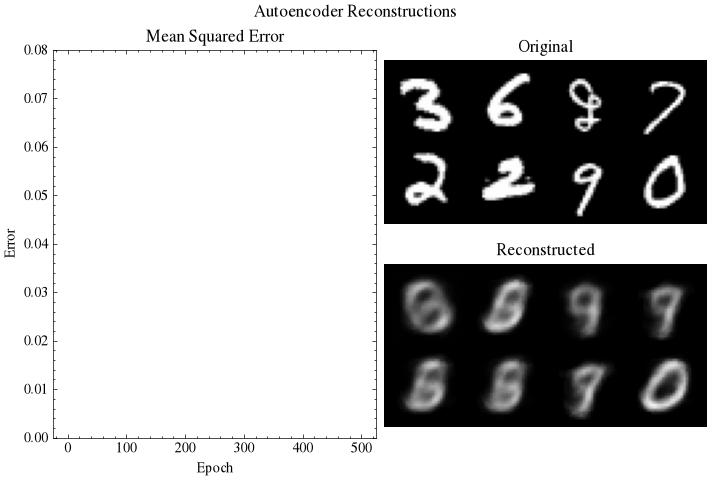

In [8]:
Image(filename=recon_filename)

## 潜在空间输出 GIF

2 神经元潜在空间的动画。每个点都是一张验证图像，由编码器投影到 $z \in \mathbb{R}^2$，并按其真实数字着色。随着训练推进，同一数字的图像会迁移、聚拢成一个个明显的簇——尽管自编码器从未见过这些标签。

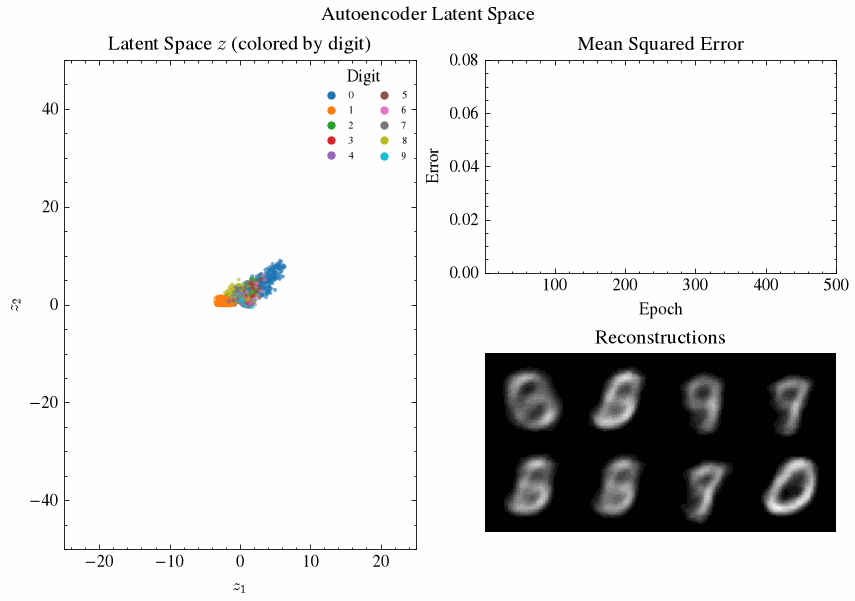

In [9]:
Image(filename=latent_filename)

## 损失景观输出 GIF

损失景观动画，包含第 1 层（编码器 $\text{Linear}(64, 2)$）和第 2 层（解码器 $\text{Linear}(2, 64)$）的 3D 曲面。蓝色与红色曲面展示了扫描每个神经元的两个权重时 MSE 的变化；标记点及其轨迹则描绘了当前权重在景观中不断下降的过程。

设置 `live_surface = True` 可以每帧根据模型的当前状态重新计算曲面（这样随着网络其余部分的继续训练，碗状曲面会发生形变）。这会更慢——保持为 `False` 则会快速地一次性绘制固定的参考曲面。

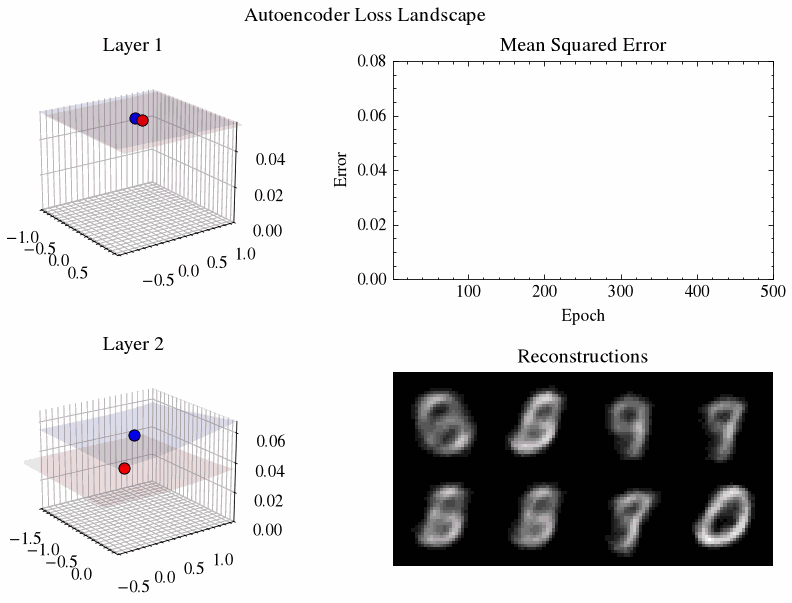

In [10]:
Image(filename=landscape_filename)